<a href="https://colab.research.google.com/github/deborarbv/PrimerRepo/blob/master/Proyecto_Final_ML_D%C3%A9bora_Vianna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto final**

**Indicaciones:**

**A. Desarrollo del Proyecto**

Implemente en Python y compare el desempeño de los siguientes algoritmos de aprendizaje supervisado:
* Regresión lineal
* Regresión logística
* Máquina de Vector de Soporte (SVM)
* Árbol de decisión

Para el desarrollo del proyecto deberá utilizar el conjunto de datos **FIFA 15**.

Realice el proceso completo de análisis de datos, incluyendo la exploración, limpieza y preparación del conjunto de datos. Asimismo, seleccione las variables de estudio que considere más relevantes para el problema planteado y justifique su elección.

El entrenamiento y evaluación de los modelos deberán realizarse utilizando la siguiente división de los datos:
* 70 % para entrenamiento (Training)
* 30 % para prueba (Test)

Posteriormente, evalúe el desempeño de cada modelo mediante las métricas correspondientes y visualice los resultados obtenidos.

Reporte técnico: El reporte deberá contener los siguientes apartados:

1. Portada

2. Introducción: Presentar una descripción general del problema abordado y los objetivos del proyecto.

3. Análisis Exploratorio de Datos: Describir el análisis realizado sobre el conjunto de datos, incluyendo los hallazgos más relevantes.

4. Selección de Variables: Justificar la elección de las variables utilizadas para el entrenamiento de los modelos.

5. Desarrollo de los modelos: Para cada algoritmo implementado, describir detalladamente
* Variables utilizadas.
* Proceso de entrenamiento.
* Configuración de parámetros.

6. Resultados y evaluación: Presentar y analizar los resultados obtenidos mediante las métricas de evaluación correspondientes. Todos los modelos deberán incluir gráficas que permitan visualizar y comparar su desempeño.

7. Comparación de modelos: Incluir una tabla comparativa que contemple los siguientes aspectos
* Métricas obtenidas (Accuracy, Precision, Recall, F1-Score y AUC, cuando aplique).
* Ventajas.
* Desventajas.
* Tiempo de entrenamiento.

8. Conclusiones: Responder de manera fundamentada las siguientes preguntas
* ¿Qué modelo obtuvo el mejor desempeño?
* ¿Cuál fue el algoritmo más rápido?
* ¿Cuál recomendaría para una organización deportiva y por qué?
* ¿Qué aprendizajes obtuvo durante el desarrollo del proyecto?

**B. Presentación**

Realizar una presentación con una duración de 10 a 15 minutos, en la que deberán explicar:
* El problema abordado.
* Los algoritmos implementados (el algoritmo a exponer será asignado durante la sesión correspondiente).
* Los resultados obtenidos.
* Las conclusiones del proyecto.

NOTA: Comparte tu código en GitHub al correo dani.fguerrero@gmail.com o al usuario iscwarrior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
archivo_asubir = files.upload()

df_local = pd.read_csv('players_15.csv')
df_local

Saving players_15.csv to players_15.csv


/tmp/ipykernel_3143/1150025952.py:4: DtypeWarning: Columns (104) have mixed types. Specify dtype option on import or set low_memory=False.
  df_local = pd.read_csv('players_15.csv')


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,...,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/105035/60.png,https://cdn.sofifa.net/flags/nl.png
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,52500000.0,275000.0,32,...,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1363/60.png,https://cdn.sofifa.net/flags/se.png
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,63500000.0,300000.0,28,...,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16150,220806,https://sofifa.com/player/220806/ellis-redman/...,E. Redman,Ellis Redman,CB,41,61,20000.0,2000.0,17,...,41,41,41,40,10,https://cdn.sofifa.net/players/220/806/15_120.png,https://cdn.sofifa.net/teams/112254/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/gb-wls.png
16151,225509,https://sofifa.com/player/225509/aaron-collins...,A. Collins,Aaron Graham John Collins,ST,41,50,30000.0,2000.0,17,...,31,31,31,32,14,https://cdn.sofifa.net/players/225/509/15_120.png,https://cdn.sofifa.net/teams/112254/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/gb-wls.png
16152,201197,https://sofifa.com/player/201197/paul-tisdale/...,P. Tisdale,Paul Tisdale,"CM, CAM",40,40,NaN,2000.0,41,...,33,33,33,34,10,https://cdn.sofifa.net/players/201/197/15_120.png,https://cdn.sofifa.net/teams/143/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/mt.png
16153,217591,https://sofifa.com/player/217591/piotr-zemlo/1...,P. Żemło,Piotr Żemło,"LM, LB",40,50,15000.0,2000.0,18,...,53-3,53-3,53-3,51-1,12,https://cdn.sofifa.net/players/217/591/15_120.png,https://cdn.sofifa.net/teams/1873/60.png,https://cdn.sofifa.net/flags/pl.png,NaN,https://cdn.sofifa.net/flags/pl.png


In [3]:
df_local.info()
df_local.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16155 entries, 0 to 16154
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: float64(17), int64(43), object(50)
memory usage: 13.6+ MB


,sofifa_id,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_level,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,16155.000000,16155.000000,16155.000000,1.584400e+04,15916.000000,16155.000000,16155.000000,16155.000000,15916.000000,15916.000000,...,0.0,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,1775.000000
mean,189298.540699,63.830393,68.350108,1.081706e+06,13252.513194,24.776230,181.083627,75.474342,39905.174353,1.378424,...,NaN,45.009037,47.656639,45.885918,15.869514,15.511668,15.354875,15.504735,15.998514,43.865915
std,39762.547872,7.169896,6.580610,2.842704e+06,23608.922510,4.625321,6.618974,6.891796,52050.202038,0.736796,...,NaN,17.915206,18.743105,18.145497,17.576799,16.414173,16.010498,16.585081,17.983209,8.484421
min,2.000000,40.000000,40.000000,1.000000e+03,2000.000000,16.000000,155.000000,50.000000,1.000000,1.000000,...,NaN,20.000000,20.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.000000
25%,178042.500000,59.000000,64.000000,1.300000e+05,2000.000000,21.000000,176.000000,70.000000,379.000000,1.000000,...,NaN,25.000000,25.000000,25.000000,8.000000,8.000000,8.000000,8.000000,8.000000,39.000000
50%,200844.000000,64.000000,68.000000,3.500000e+05,5000.000000,24.000000,181.000000,75.000000,1843.000000,1.000000,...,NaN,46.000000,52.000000,49.000000,11.000000,11.000000,11.000000,10.000000,10.000000,44.000000
75%,214349.500000,68.000000,73.000000,8.250000e+05,10000.000000,28.000000,186.000000,80.000000,110398.000000,2.000000,...,NaN,61.000000,64.000000,62.000000,13.000000,14.000000,13.000000,13.000000,13.000000,49.000000
max,254664.000000,93.000000,95.000000,1.005000e+08,550000.000000,44.000000,204.000000,110.000000,113147.000000,4.000000,...,NaN,90.000000,91.000000,95.000000,88.000000,87.000000,92.000000,90.000000,90.000000,66.000000


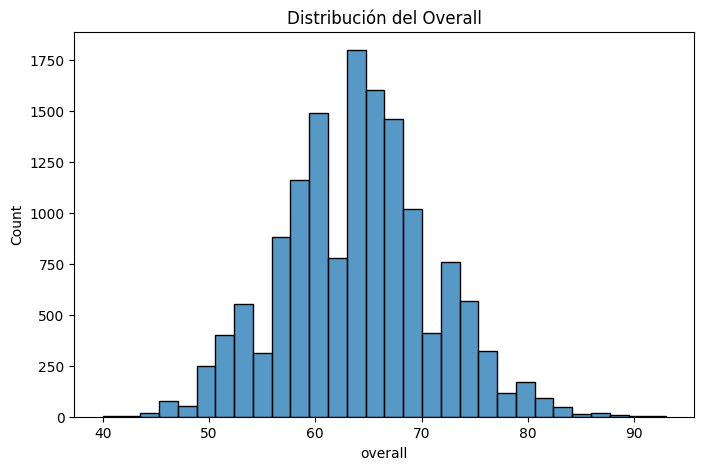

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df_local['overall'], bins=30)
plt.title('Distribución del Overall')
plt.show()

In [4]:
# limpiar columnas irrelevantes
cols_irrelevantes = [
    'player_url', 'player_face_url',
    'club_logo_url', 'club_flag_url',
    'nation_logo_url', 'nation_flag_url',
    'sofifa_id'
]

df_local = df_local.drop(columns=cols_irrelevantes, errors='ignore')

# selección de variables
features = ['age', 'potential', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

# eliminar nulos SOLO en features
df_local = df_local.dropna(subset=features)

In [5]:
df_local.info()
df_local.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 14380 entries, 0 to 16154
Columns: 103 entries, short_name to gk
dtypes: float64(17), int64(42), object(44)
memory usage: 11.4+ MB


,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_level,club_jersey_number,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,14380.000000,14380.000000,1.410600e+04,14178.000000,14380.000000,14380.000000,14380.000000,14178.000000,14178.000000,14178.000000,...,0.0,14380.000000,14380.000000,14380.000000,14380.000000,14380.000000,14380.000000,14380.000000,14380.000000,0.0
mean,63.967803,68.521349,1.092622e+06,13415.361828,24.658832,180.263769,74.664465,39829.715122,1.380590,19.631471,...,NaN,47.484840,50.461196,48.476147,9.851391,9.925730,9.921210,9.870862,9.844784,NaN
std,7.092104,6.530495,2.861114e+06,23750.981364,4.490001,6.342018,6.509202,52035.024023,0.738808,16.125761,...,NaN,17.456998,17.972728,17.572068,3.155601,3.137402,3.167527,3.133992,3.177630,NaN
min,40.000000,40.000000,1.000000e+03,2000.000000,16.000000,155.000000,50.000000,1.000000,1.000000,1.000000,...,NaN,20.000000,20.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,59.000000,64.000000,1.300000e+05,2000.000000,21.000000,176.000000,70.000000,382.500000,1.000000,8.000000,...,NaN,28.000000,32.000000,29.000000,7.000000,7.000000,7.000000,7.000000,7.000000,NaN
50%,64.000000,68.000000,3.750000e+05,5000.000000,24.000000,180.000000,75.000000,1843.000000,1.000000,17.000000,...,NaN,51.000000,56.000000,53.000000,10.000000,10.000000,10.000000,10.000000,10.000000,NaN
75%,68.000000,73.000000,8.500000e+05,10000.000000,28.000000,185.000000,79.000000,110398.000000,2.000000,26.000000,...,NaN,62.000000,65.000000,63.000000,13.000000,13.000000,13.000000,13.000000,13.000000,NaN
max,93.000000,95.000000,1.005000e+08,550000.000000,41.000000,204.000000,110.000000,113147.000000,4.000000,99.000000,...,NaN,90.000000,91.000000,95.000000,52.000000,41.000000,46.000000,48.000000,57.000000,NaN


In [7]:
# crear variable objetivo
df_local['Elite'] = np.where(df_local['overall'] >= 80, 1, 0)
y_reg = df_local['overall']

In [8]:
#entrenamiento

from sklearn.model_selection import train_test_split

X = df_local[features]
y_class = df_local['Elite']
y_reg = df_local['overall']

X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.3, random_state=42)

_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.3, random_state=42)


In [9]:
#normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
#modelo regresión lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_lr = LinearRegression()
model_lr.fit(X_train, y_train_reg)

y_pred_lr = model_lr.predict(X_test)

print("R2:", r2_score(y_test_reg, y_pred_lr))
print("MSE:", mean_squared_error(y_test_reg, y_pred_lr))

#obtener la ecuación
coeficientes = model_lr.coef_
intercepto = model_lr.intercept_

ecuacion = "overall = " + str(round(intercepto, 4))

for coef, feature in zip(coeficientes, features):
    ecuacion += " + (" + str(round(coef, 4)) + " * " + feature + ")"

print("Ecuación del modelo:\n")
print(ecuacion)

R2: 0.9181386032845718
MSE: 4.129337931315602
Ecuación del modelo:

overall = -18.1261 + (0.6324 * age) + (0.7467 * potential) + (0.033 * pace) + (0.0403 * shooting) + (0.0242 * passing) + (0.0435 * dribbling) + (0.0324 * defending) + (0.0838 * physic)


In [22]:
#modelo regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train_scaled, y_train_class)

y_pred_log = model_log.predict(X_test_scaled)

print(classification_report(y_test_class, y_pred_log))
print("AUC:", roc_auc_score(y_test_class, model_log.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4238
           1       0.89      0.78      0.83        76

    accuracy                           0.99      4314
   macro avg       0.94      0.89      0.91      4314
weighted avg       0.99      0.99      0.99      4314

AUC: 0.9979694990189018


In [24]:
#SVM
from sklearn.svm import SVC

model_svm = SVC(probability=True)
model_svm.fit(X_train_scaled, y_train_class)

y_pred_svm = model_svm.predict(X_test_scaled)

print(classification_report(y_test_class, y_pred_svm))
print("AUC:", roc_auc_score(y_test_class, model_svm.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4238
           1       0.95      0.74      0.83        76

    accuracy                           0.99      4314
   macro avg       0.97      0.87      0.91      4314
weighted avg       0.99      0.99      0.99      4314

AUC: 0.9984755718933955


In [25]:
#árbol de decisión
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(max_depth=5)
model_tree.fit(X_train, y_train_class)

y_pred_tree = model_tree.predict(X_test)

print(classification_report(y_test_class, y_pred_tree))
print("AUC:", roc_auc_score(y_test_class, model_tree.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4238
           1       0.91      0.88      0.89        76

    accuracy                           1.00      4314
   macro avg       0.95      0.94      0.95      4314
weighted avg       1.00      1.00      1.00      4314

AUC: 0.9914976652343459
